## 4.7 Lab: Logistic Regression, LDA, QDA, and KNN

In [75]:
# In[1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize
from ISLP import confusion_table
from ISLP.models import contrast

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


### Now we are ready to load the Smarket data.

In [2]:
# In[3]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


#### This gives a truncated listing of the data, which we do not show here. We can see what the variable names are

In [3]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

#### We compute the correlation matrix using the corr() method for data .corr() frames,

In [4]:
# Smarket.corr()
Smarket.corr(numeric_only=True)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


#### the correlations between the lagged return variables and today’s return are close to zero.

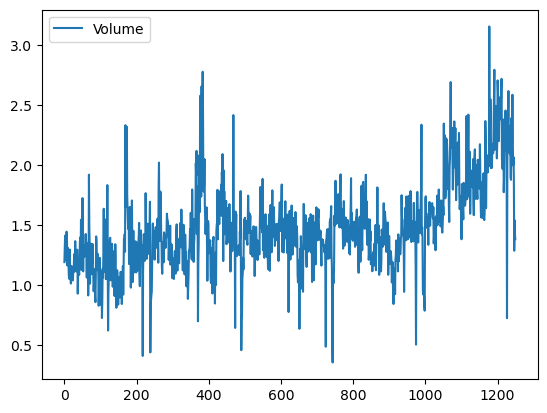

In [5]:
Smarket.plot(y='Volume');

#### 4.7.2 Logistic Regression

#### The smallest p-value here is associated with Lag1

In [6]:
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Smarket)
y = Smarket.Direction == 'Up'
glm = sm.GLM(y,X,family=sm.families.Binomial())
results = glm.fit()
summarize(results)


,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


#### Likewise we can use the pvalues attribute to access the p-values for the coefficients 

In [7]:
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

In [8]:
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

##### The predict() method of results can be used to predict the probability that the market will go up, given values of the predictors

In [9]:
probs = results.predict()
probs[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

##### The following two commands create a vector of class predictions based on whether the predicted probability of a market increase is greater than or less than 0.5.

In [10]:
labels = np.array(['Down']*1250)
labels[probs>0.5] = "Up"

#### Confusion table

In [11]:

confusion_table(labels, Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


#### The diagonal elements of the confusion matrix indicate correct predictions

In [12]:
(507+145)/1250, np.mean(labels == Smarket.Direction)

(0.5216, np.float64(0.5216))

#### At first glance, it appears that the logistic regression model is working a little better than random guessing,.... To implement this strategy, we first create a Boolean vector corresponding to the observations from 2001 through 2004. We then use this vector to create a held out data set of observations from 2005.

In [13]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[ train]
Smarket_test.shape

(998, 9)

In [24]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,X_train,
family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [25]:
D = Smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]

#### Now wethreshold the fitted probability at 50% to form our predicted labels.

In [16]:
labels = np.array(['Down']*252)
labels[probs>0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


#### The test accuracy is about 48% while the error rate is about 52%

In [17]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.4801587301587302), np.float64(0.5198412698412699))

#### Below we refit the logistic regression using just Lag1 and Lag2, which seemed to have the highest predictive power in the original logistic regression model.

In [18]:
# model = MS(['Lag1', 'Lag2']).fit(Smarket)
# X = model.transform(Smarket)
# X_train, X_test = X.loc[train], X.loc[ train]
# glm_train = sm.GLM(y_train,
# X_train,
# family=sm.families.Binomial())
# results = glm_train.fit()
# probs = results.predict(exog=X_test)
# labels = np.array(['Down']*252)
# labels[probs>0.5] = 'Up'
# confusion_table(labels, L_test)

In [19]:
# Train / test split
train = Smarket['Year'] < 2005
test  = Smarket['Year'] == 2005

# Numeric response for GLM
y = (Smarket['Direction'] == 'Up').astype(int)
y_train = y.loc[train]

# Labels for confusion matrix
L_test = Smarket.loc[test, 'Direction']

# Model matrix
model = MS(['Lag1', 'Lag2']).fit(Smarket)
X = model.transform(Smarket)

X_train, X_test = X.loc[train], X.loc[test]

# Logistic regression (GLM)
glm_train = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial()
)

results = glm_train.fit()

# Predictions
probs = results.predict(exog=X_test)
labels = np.where(probs > 0.5, 'Up', 'Down')

confusion_table(labels, L_test)



Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [20]:
print(
    X_train.shape,
    X_test.shape,
    len(y_train),
    len(L_test)
)


(998, 3) (252, 3) 998 252


In [21]:
(35+106)/252,106/(106+76)

(0.5595238095238095, 0.5824175824175825)

Now the results appear to be a little better: 56% of the daily movements
have been correctly predicted. It is worth noting that in this case, a much
simpler strategy of predicting that the market will increase every day will
also be correct 56% of the time! 

#### Suppose that we want to predict the returns associated with particular values of Lag1 and Lag2

In [28]:
newdata = pd.DataFrame({'Lag1':[1.2, 1.5],'Lag2':[1.1,-0.8]});
newX = model.transform(newdata)
results.predict(newX)

0    0.479146
1    0.496094
dtype: float64

#### 4.7.3 LinearDiscriminant Analysis

In [33]:
lda = LDA(store_covariance=True)

#### SincetheLDAestimatorautomaticallyaddsan intercept,we should remove the column corresponding to the intercept in both X_train and X_test.We can also directly use the labels rather than the Boolean vectors y_train.

In [34]:
X_train, X_test = [M.drop(columns=['intercept'])
for M in [X_train, X_test]]
lda.fit(X_train, L_train)

KeyError: "['intercept'] not found in axis"

In [ ]:
lda.means_

#### The estimated prior probabilities are stored in the priors_attribute.

In [36]:
 lda.classes_

AttributeError: 'LinearDiscriminantAnalysis' object has no attribute 'classes_'

#### The LDA output indicates that ˆDown =0.492 and ˆUp =0.508

In [ ]:
lda_pred = lda.predict(X_test)

#### the LDA and logistic regression predictions are almost identical.

In [ ]:
confusion_table(lda_pred, L_test)

In [ ]:
lda_prob = lda.predict_proba(X_test)
np.all(
    np.where(lda_prob[:,1] >= 0.5, 'Up','Down') == lda_pred)


In [ ]:
For problems with more than two classes the labels are chosen as the class whose posterior probability is highest:

In [26]:
np.all(
[lda.classes_[i] for i in np.argmax(lda_prob, 1)] ==
lda_pred
)

NameError: name 'lda_prob' is not defined

In [ ]:
np.sum(lda_prob[:,0] > 0.9)

#### 4.7.4 Quadratic Discriminant Analysis

In [ ]:

qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

In [ ]:
qda.means_, qda.priors_

#### The QDA() classifier will estimate one covariance per class.

In [ ]:
qda.covariance_[0]

####  The predict() function works in exactly the same fashion as for LDA.


In [ ]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

This level of accuracy is quite impressive for stock market data, which
is known to be quite hard to model accurately. This suggests that the
quadratic form assumed by QDA may capture the true relationship more
accurately than the linear forms assumed by LDA and logistic regression.

In [ ]:
np.mean(qda_pred == L_test)

## 4.7.5 Naive Bayes

In [ ]:
NB = GaussianNB()
NB.fit(X_train, L_train)

#### The classes are stored as classes_.

In [ ]:
NB.classes_

#### The class prior probabilities are stored in the class_prior_ attribute

In [ ]:
NB.class_prior_

####  The number of rows is equal to the number of classes, while the number of columns is equal to the number of features

In [ ]:
NB.theta_

### Its variance is 1.503.

In [ ]:
NB.var_

In [ ]:
X_train[L_train == 'Down'].mean()

#### Similarly for the variance:

In [ ]:
X_train[L_train == 'Down'].var(ddof=0)

#### The GaussianNB() function calculates variances using the 1/n formula

In [ ]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, L_test)

#### As for LDA, the predict_proba() method estimates the probability that each observation belongs to a particular class.

In [ ]:
NB.predict_proba(X_test)[:5]

#### 4.7.6 K-Nearest Neighbors

In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

In [ ]:
(83+43)/252, np.mean(knn1_pred == L_test)

#### We repeat the analysis below using K =3

In [ ]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train, L_train).predict(X_test)
np.mean(knn3_pred == L_test)

In [ ]:
### 
Caravan = load_data('Caravan')
Purchase = Caravan.Purchase
Purchase.value_counts()

#### In this case Purchase has only Yes and No values and returns how many values of each there are.


In [ ]:
348 / 5822

#### Our features will include all columns except Purchase.

In [ ]:
feature_df = Caravan.drop(columns=['Purchase'])

In [ ]:
scaler = StandardScaler(with_mean=True, with_std=True, copy=True)

In [ ]:
scaler.fit(feature_df)
X_std = scaler.transform(feature_df)

In [ ]:
feature_std = pd.DataFrame(X_std, columns=feature_df.columns);
feature_std.std()

In [ ]:
#### Notice that the standard deviations are not quite 1 here; this is again due to some procedures using the 1/n convention for variances

#### Using the function train_test_split() we now split the observations into train_test_ a test set

In [ ]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(
     feature_std,
     Purchase,
     test_size=1000,
     random_state=0
)


In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(y_test != knn1_pred), np.mean(y_test != "No")

#### Confusion Table

In [ ]:
confusion_table(knn1_pred, y_test)

### This is double the rate that one would obtain from random guessing.

In [49]:
9/(53+9)

0.14516129032258066

#### Tuning Parameters

In [43]:
C = confusion_table(knn_pred, y_test)
print(C)
print(C.index)
print(C.columns)


Truth       0   1
Predicted        
0          43  58
1          68  83
Index([0, 1], dtype='int64', name='Predicted')
Index([0, 1], dtype='int64', name='Truth')


In [8]:
# for K in range(1,6):
    # knn = KNeighborsClassifier(n_neighbors=K)
    # knn_pred = knn.fit(X_train, y_train).predict(X_test)
    # C = confusion_table(knn_pred, y_test)
    # templ = ('K={0:d}: # predicted to rent: {1:>2},' +' # who did rent {2:d}, accuracy {3:.1%}')
    # pred = C.loc['Yes'].sum()
    # did_rent = C.loc['Yes','Yes']
    # print(templ.format(
    #     K,
    #     pred,
    #     did_rent,
    #     did_rent / pred))

In [10]:
# logit = LogisticRegression(C=1e10, solver='liblinear')
# logit.fit(X_train, y_train)
# logit_pred = logit.predict_proba(X_test)
# logit_labels = np.where(logit_pred[:,1] > 5, 'Yes', 'No')
# confusion_table(logit_labels, y_test)

In [12]:
# logit_labels = np.where(logit_pred[:,1]>0.25, 'Yes', 'No')
# confusion_table(logit_labels, y_test)

In [53]:
9/(20+9)

0.3103448275862069

#### 4.7.7 Linear and Poisson Regression on the Bikeshare Data

Here we fit linear and Poisson regression models to the Bikeshare data, as
described in Section 4.6. The response bikers measures the number of bike
rentals per hour in Washington, DC in the period 2010–2012.

In [54]:
Bike = load_data('Bikeshare')

In [55]:
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

#### LinearRegression


In [ ]:
We begin by fitting a linear regression model to the data.

In [56]:
 X = MS(['mnth',
'hr',
'workingday',
'temp',
'weathersit']).fit_transform(Bike)
Y = Bike['bikers']
M_lm = sm.OLS(Y, X).fit()
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In [57]:
hr_encode = contrast('hr', 'sum')
mnth_encode = contrast('mnth', 'sum')

##### Refitting again:

In [58]:
 X2 = MS([mnth_encode,
hr_encode,
'workingday',
'temp',
'weathersit']).fit_transform(Bike)
M2_lm = sm.OLS(Y, X2).fit()
S2 = summarize(M2_lm)
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


we see that the predictions from the linear model are
the same regardless of coding:

In [59]:
 np.sum((M_lm.fittedvalues- M2_lm.fittedvalues)**2)

np.float64(1.5537785308829017e-20)

In [60]:
 np.allclose(M_lm.fittedvalues, M2_lm.fittedvalues)

True

In [61]:
 coef_month = S2[S2.index.str.contains('mnth')]['coef']
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
Name: coef, dtype: float64

Next,we append Dec as the negative of the sum of all other months.

months = Bike['mnth'].dtype.categories
coef_month = pd.concat([
coef_month,
pd.Series([-coef_month.sum()],
index=['mnth[Dec]'
])
])
coef_month

In [ ]:
Finally,to make the plot neater,we’ll just use the first letter of each month,
which is the 6th entry of each of the labels in the index

Text(0, 0.5, 'Coefficient')

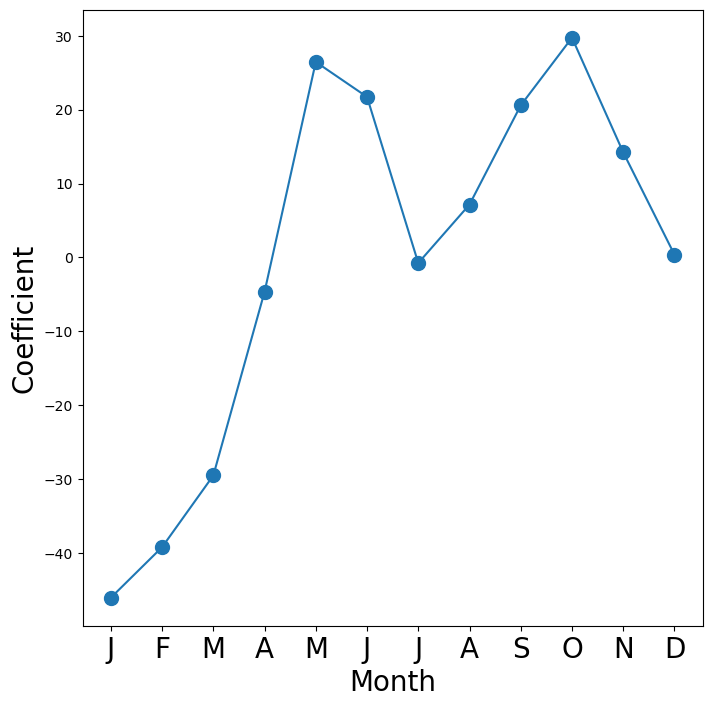

In [65]:
import matplotlib.pyplot as plt

fig_month, ax_month = plt.subplots(figsize=(8, 8))

x_month = np.arange(coef_month.shape[0])
ax_month.plot(x_month, coef_month, marker='o', ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize=20)
ax_month.set_xlabel('Month', fontsize=20)
ax_month.set_ylabel('Coefficient', fontsize=20)


### Reproducing the right-hand plot 

In [67]:
 coef_hr = S2[S2.index.str.contains('hr')]['coef']
coef_hr = coef_hr.reindex(['hr[{0}]'.format(h) for h in range(23)])
coef_hr = pd.concat([coef_hr,pd.Series([-coef_hr.sum()], index=['hr[23]'])
])


Text(0, 0.5, 'Coefficient')

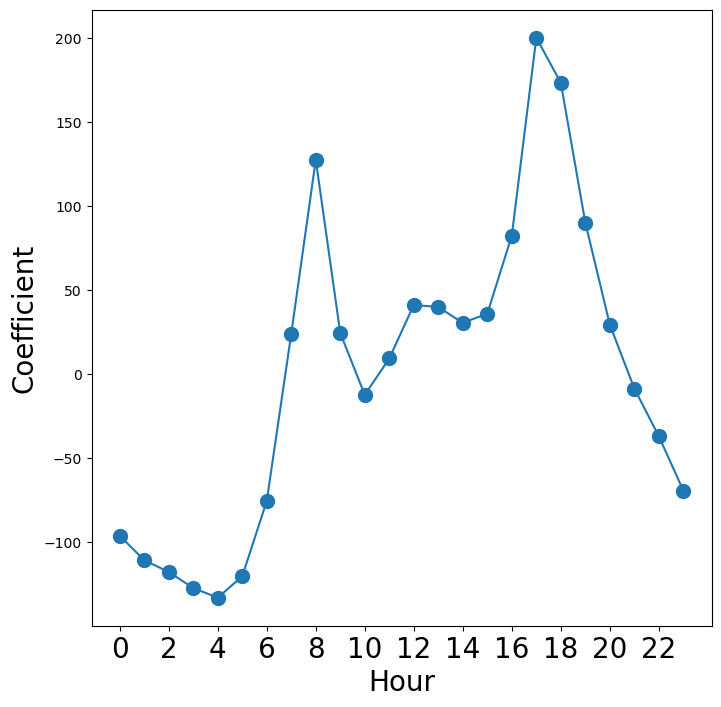

In [69]:
import matplotlib.pyplot as plt

fig_hr, ax_hr = plt.subplots(figsize=(8, 8))

x_hr = np.arange(coef_hr.shape[0])
ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)

ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)

ax_hr.set_xlabel('Hour', fontsize=20)
ax_hr.set_ylabel('Coefficient', fontsize=20)


### Poisson Regression

In [70]:
 M_pois = sm.GLM(Y, X2, family=sm.families.Poisson()).fit()

In [71]:
 S_pois = summarize(M_pois)
coef_month = S_pois[S_pois.index.str.contains('mnth')]['coef']
coef_month = pd.concat([coef_month,
pd.Series([-coef_month.sum()],
index=['mnth[Dec]'])])
coef_hr = S_pois[S_pois.index.str.contains('hr')]['coef']
coef_hr = pd.concat([coef_hr,
pd.Series([-coef_hr.sum()],
index=['hr[23]'])])

#### The plotting is as before

Text(0, 0.5, 'Coefficient')

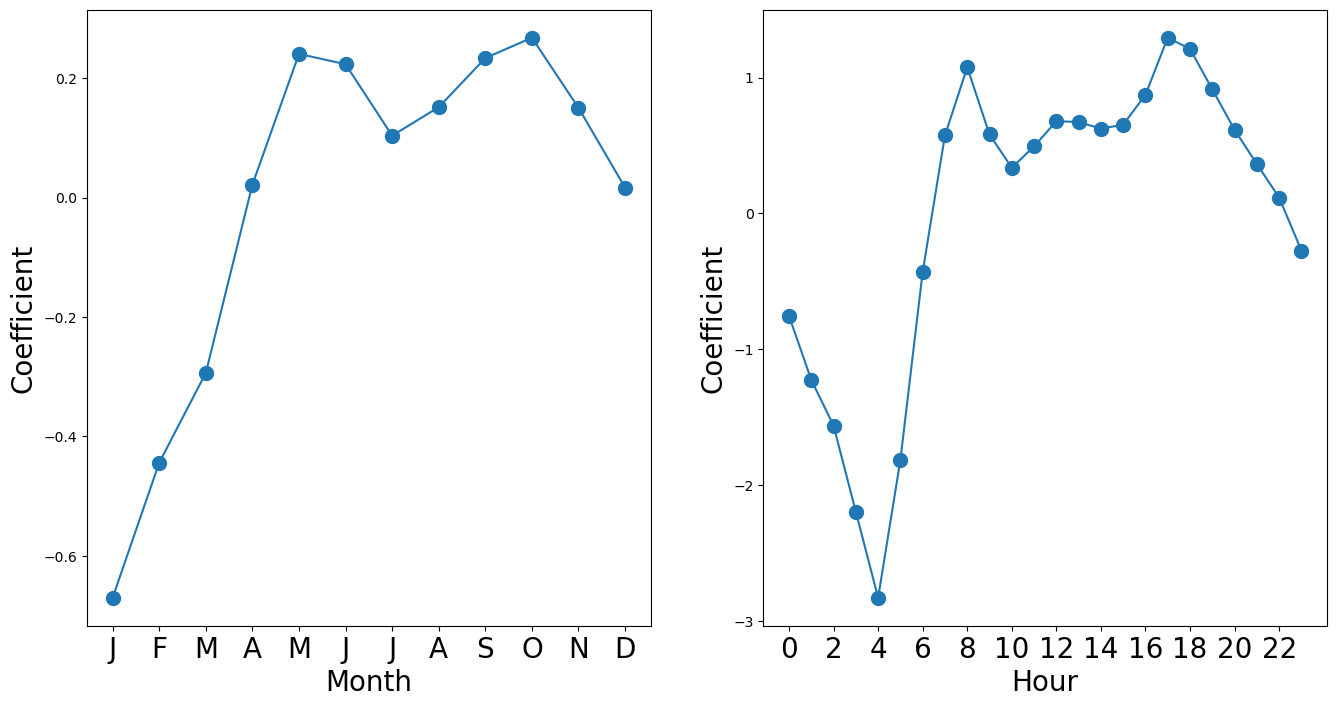

In [73]:
fig_pois, (ax_month, ax_hr) = plt.subplots(1, 2, figsize=(16,8))

ax_month.plot(x_month, coef_month, marker='o', ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize=20)
ax_month.set_xlabel('Month', fontsize=20)
ax_month.set_ylabel('Coefficient', fontsize=20)

ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)
ax_hr.set_xticks(x_hr[::2])
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour', fontsize=20)
ax_hr.set_ylabel('Coefficient', fontsize=20)


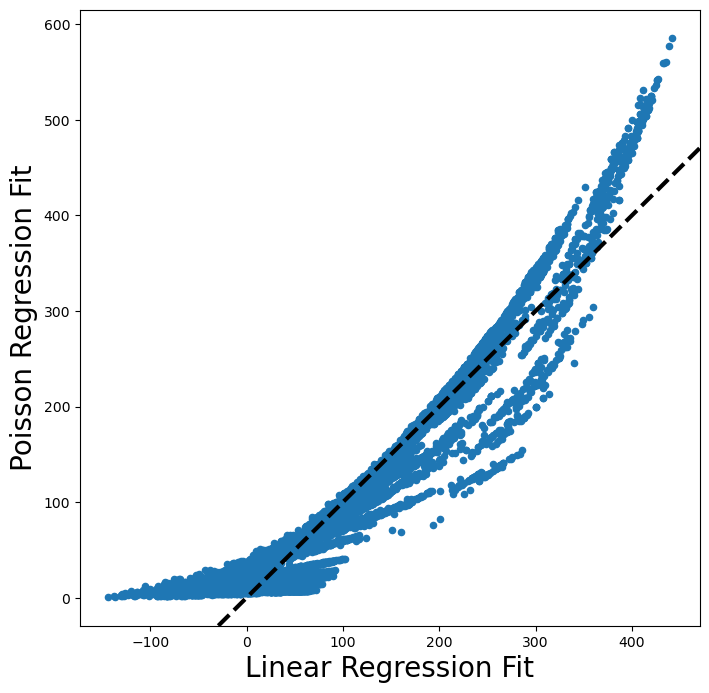

In [79]:
import matplotlib.pyplot as plt   # make sure this is at the top of your notebook

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    M2_lm.fittedvalues,
    M_pois.fittedvalues,
    s=20
)

ax.set_xlabel('Linear Regression Fit', fontsize=20)
ax.set_ylabel('Poisson Regression Fit', fontsize=20)

# 45-degree reference line
ax.axline([0, 0], slope=1, color='black', linewidth=3, linestyle='--')


